# Participant Analysis

In [29]:
# imports

import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.chdir("/Users/saachi/Desktop/Search-to-Change")

In [31]:


os.chdir("/Users/saachi/Desktop/Search-to-Change")
print(os.listdir("processed_data/"))


['search_converted.csv', '.DS_Store', 'Reconciled_Data_Full.csv', 'Reconciled_Final.csv']


In [ ]:
#data = "/Users/saachi/Desktop/Search-to-Change/processed_data/Reconciled_Data_Full.csv"
#df = pd.read_csv(data)
#df

df = pd.read_csv("processed_data/search_log_analysis.csv", encoding="latin-1")
df = df.rename(columns={"week no": "week_no"})
df = df[df["data"] == "Q"].reset_index(drop=True)
df

Rows after filtering to queries only: 2115


,participant_no,week_no,url,query,data,type,task,goal,source,content,format
0,102,Week 1,https://www.google.com/search?q=foods to avoid...,foods to avoid while losing body fat,Q,ideas/options,option seeking,plan,NaN,NaN,NaN
1,102,Week 1,https://www.google.com/search?q=foods to avoid...,foods to avoid while losing body fat,Q,ideas/options,option seeking,plan,NaN,NaN,NaN
2,102,Week 1,https://www.google.com/search?q=foods to eat t...,foods to eat that help lose weight,Q,ideas/options,option seeking,plan,NaN,NaN,NaN
3,102,Week 1,https://www.google.com/search?q=foods to eat t...,foods to eat that help lose weight,Q,ideas/options,option seeking,plan,NaN,NaN,NaN
4,102,Week 1,https://www.google.com/search?q=vegan foods to...,vegan foods to eat that help lose weight,Q,ideas/options,option seeking,plan,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2110,135,Week 4,https://www.google.com/search?q=Meadowbrook Park,Meadowbrook Park,Q,factual,logistics,decision making,NaN,NaN,NaN
2111,135,Week 4,https://www.google.com/search?q=Meadowbrook Park,Meadowbrook Park,Q,factual,logistics,decision making,NaN,NaN,NaN
2112,135,Week 4,https://www.google.com/search?q=Meadowbrook Pa...,Meadowbrook Park urbana,Q,factual,logistics,decision making,NaN,NaN,NaN
2113,135,Week 4,https://www.google.com/search?q=post workout meal,post workout meal,Q,ideas/options,option seeking,plan,NaN,NaN,NaN


In [52]:
## Analysis 1 - Unique Queries per Participant

rows = []
for pid, grp in df.groupby("participant_no"):
    total  = len(grp)
    unique = grp["query"].nunique()
    weeks  = grp["week_no"].nunique()
    rows.append(dict(
        participant      = pid,
        total_queries    = total,
        unique_queries   = unique,
        repeat_rate      = round((total - unique) / total, 3),
        weeks_active     = weeks,
        queries_per_week = round(total / weeks, 1),
    ))

uq = pd.DataFrame(rows).set_index("participant")
uq

,total_queries,unique_queries,repeat_rate,weeks_active,queries_per_week
participant,,,,,
102,201,140,0.303,4,50.2
103,39,21,0.462,4,9.8
107,37,15,0.595,3,12.3
108,49,39,0.204,4,12.2
109,253,117,0.538,4,63.2
111,42,38,0.095,4,10.5
112,179,104,0.419,4,44.8
113,147,69,0.531,4,36.8
114,115,56,0.513,4,28.8


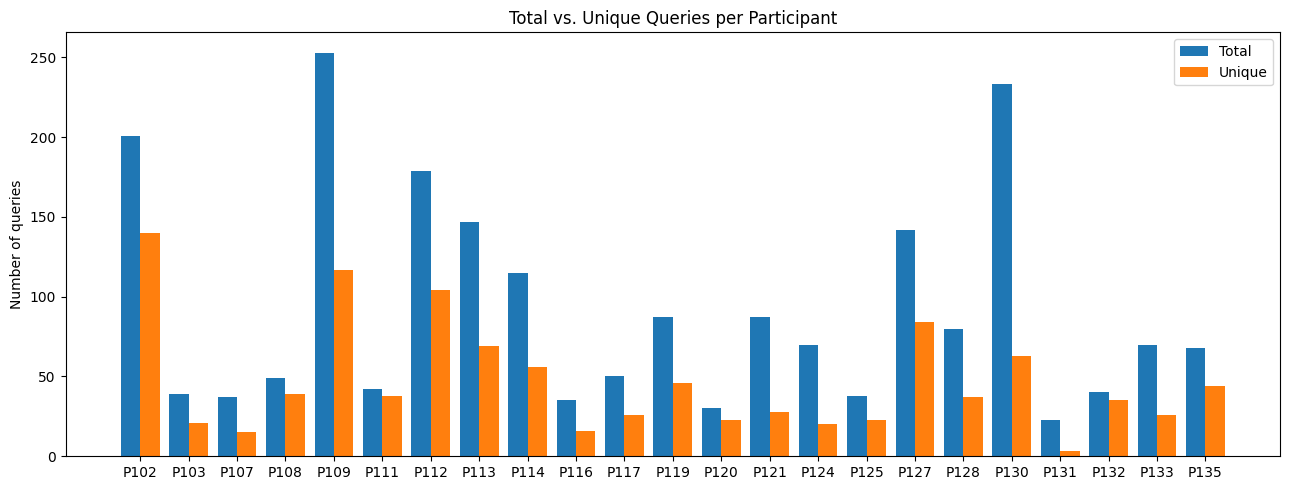

In [53]:
participants = sorted(df["participant_no"].unique())

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(participants))

ax.bar(x - 0.2, uq["total_queries"],  0.4, label="Total")
ax.bar(x + 0.2, uq["unique_queries"], 0.4, label="Unique")

ax.set_xticks(x)
ax.set_xticklabels([f"P{p}" for p in participants])
ax.set_ylabel("Number of queries")
ax.set_title("Total vs. Unique Queries per Participant")
ax.legend()
plt.tight_layout()
plt.show()

In [54]:
def analysis_query_patterns(df: pd.DataFrame) -> dict[str, pd.DataFrame]:
    dims = {"type": "Info Type", "task": "Task", "goal": "Goal"}
    tables = {}
    for col, label in dims.items():
        ct = pd.crosstab(df["participant_no"], df[col], normalize="index") * 100
        ct.index.name = "participant"
        tables[label] = ct.round(1)
    return tables

patterns = analysis_query_patterns(df)

In [55]:
def proportion_profile(df: pd.DataFrame, col: str) -> pd.DataFrame:
    return (
        df[df[col] != "na"]
        .groupby(["participant_no", col])
        .size()
        .unstack(fill_value=0)
        .apply(lambda row: row / row.sum(), axis=1)
        .round(3)
    )

prof_type = proportion_profile(df, "type")
prof_task = proportion_profile(df, "task")
prof_goal = proportion_profile(df, "goal")

prof_type.columns = [f"type_{c}" for c in prof_type.columns]
prof_task.columns = [f"task_{c}" for c in prof_task.columns]
prof_goal.columns = [f"goal_{c}" for c in prof_goal.columns]

patterns_df = prof_type.join(prof_task).join(prof_goal)
patterns_df

,type_comparative,type_experiential,type_factual,type_how-to (procedural),type_how-to (psyc),type_ideas/options,type_mechanism,type_normative,type_outcome,type_utility,task_barrier,task_evaluate,task_learn,task_logistics,task_option seeking,task_perform,goal_action,goal_decision making,goal_motivational reasoning,goal_plan
participant_no,,,,,,,,,,,,,,,,,,,,
102,0.035,0.030,0.250,0.015,0.005,0.220,0.035,0.185,0.150,0.075,0.005,0.225,0.390,0.095,0.200,0.085,0.122,0.274,0.112,0.492
103,0.000,0.000,0.128,0.103,0.000,0.769,0.000,0.000,0.000,0.000,0.000,0.000,0.205,0.000,0.795,0.000,0.000,0.000,0.000,1.000
107,0.057,0.000,0.000,0.000,0.000,0.371,0.000,0.429,0.143,0.000,0.057,0.486,0.171,0.000,0.286,0.000,0.000,0.486,0.143,0.371
108,0.000,0.056,0.222,0.000,0.000,0.278,0.000,0.083,0.000,0.361,0.000,0.000,0.250,0.194,0.250,0.306,0.417,0.056,0.167,0.361
109,0.000,0.005,0.160,0.082,0.026,0.418,0.031,0.088,0.149,0.041,0.031,0.051,0.533,0.046,0.338,0.000,0.061,0.184,0.107,0.648
111,0.048,0.000,0.048,0.000,0.000,0.452,0.071,0.071,0.262,0.048,0.000,0.143,0.452,0.000,0.357,0.048,0.098,0.366,0.244,0.293
112,0.000,0.011,0.159,0.114,0.000,0.625,0.017,0.017,0.017,0.040,0.068,0.017,0.222,0.034,0.642,0.017,0.096,0.135,0.034,0.736
113,0.000,0.007,0.156,0.054,0.000,0.721,0.000,0.048,0.014,0.000,0.020,0.020,0.272,0.061,0.626,0.000,0.109,0.429,0.000,0.463
114,0.000,0.027,0.125,0.321,0.000,0.482,0.000,0.027,0.000,0.018,0.107,0.036,0.455,0.018,0.384,0.000,0.018,0.054,0.143,0.786


In [56]:
type_df = patterns_df.filter(like="type_")
task_df = patterns_df.filter(like="task_")
goal_df = patterns_df.filter(like="goal_")

In [57]:
type_df

,type_comparative,type_experiential,type_factual,type_how-to (procedural),type_how-to (psyc),type_ideas/options,type_mechanism,type_normative,type_outcome,type_utility
participant_no,,,,,,,,,,
102,0.035,0.030,0.250,0.015,0.005,0.220,0.035,0.185,0.150,0.075
103,0.000,0.000,0.128,0.103,0.000,0.769,0.000,0.000,0.000,0.000
107,0.057,0.000,0.000,0.000,0.000,0.371,0.000,0.429,0.143,0.000
108,0.000,0.056,0.222,0.000,0.000,0.278,0.000,0.083,0.000,0.361
109,0.000,0.005,0.160,0.082,0.026,0.418,0.031,0.088,0.149,0.041
111,0.048,0.000,0.048,0.000,0.000,0.452,0.071,0.071,0.262,0.048
112,0.000,0.011,0.159,0.114,0.000,0.625,0.017,0.017,0.017,0.040
113,0.000,0.007,0.156,0.054,0.000,0.721,0.000,0.048,0.014,0.000
114,0.000,0.027,0.125,0.321,0.000,0.482,0.000,0.027,0.000,0.018


In [58]:
task_df

,task_barrier,task_evaluate,task_learn,task_logistics,task_option seeking,task_perform
participant_no,,,,,,
102,0.005,0.225,0.390,0.095,0.200,0.085
103,0.000,0.000,0.205,0.000,0.795,0.000
107,0.057,0.486,0.171,0.000,0.286,0.000
108,0.000,0.000,0.250,0.194,0.250,0.306
109,0.031,0.051,0.533,0.046,0.338,0.000
111,0.000,0.143,0.452,0.000,0.357,0.048
112,0.068,0.017,0.222,0.034,0.642,0.017
113,0.020,0.020,0.272,0.061,0.626,0.000
114,0.107,0.036,0.455,0.018,0.384,0.000


In [59]:
goal_df

,goal_action,goal_decision making,goal_motivational reasoning,goal_plan
participant_no,,,,
102,0.122,0.274,0.112,0.492
103,0.000,0.000,0.000,1.000
107,0.000,0.486,0.143,0.371
108,0.417,0.056,0.167,0.361
109,0.061,0.184,0.107,0.648
111,0.098,0.366,0.244,0.293
112,0.096,0.135,0.034,0.736
113,0.109,0.429,0.000,0.463
114,0.018,0.054,0.143,0.786


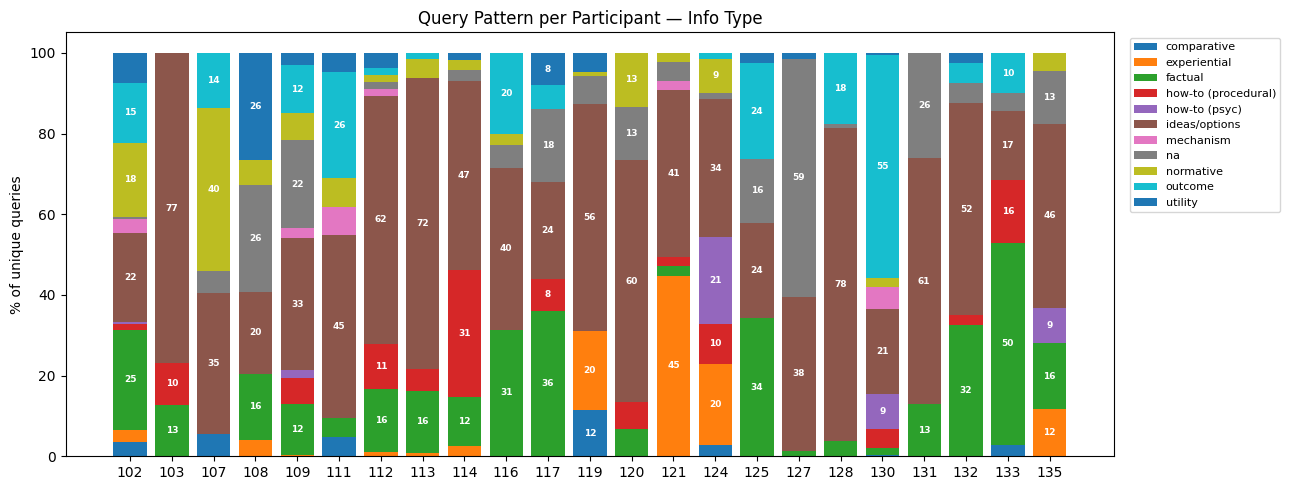

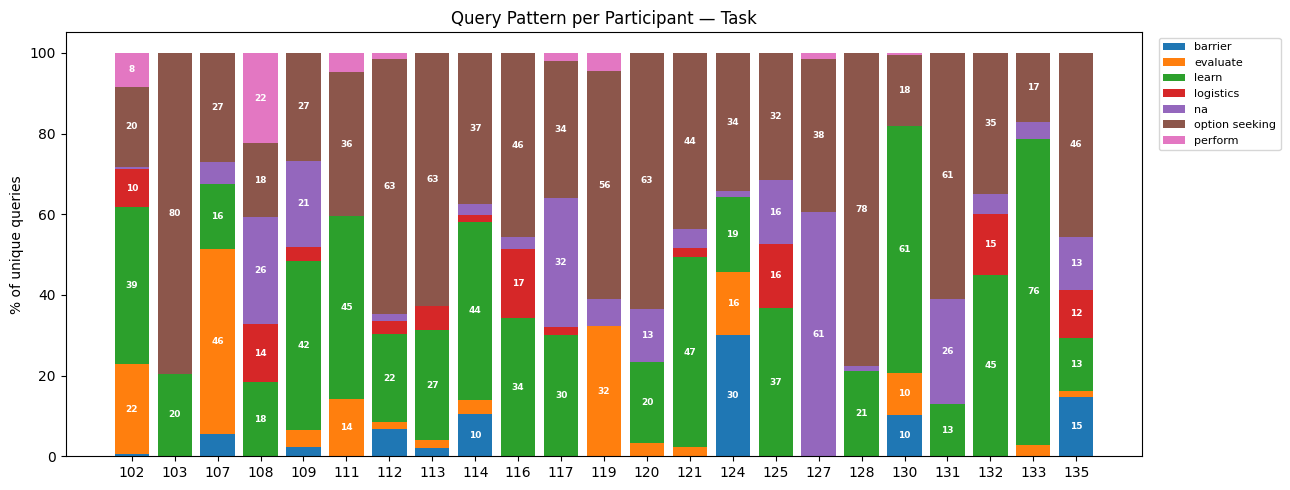

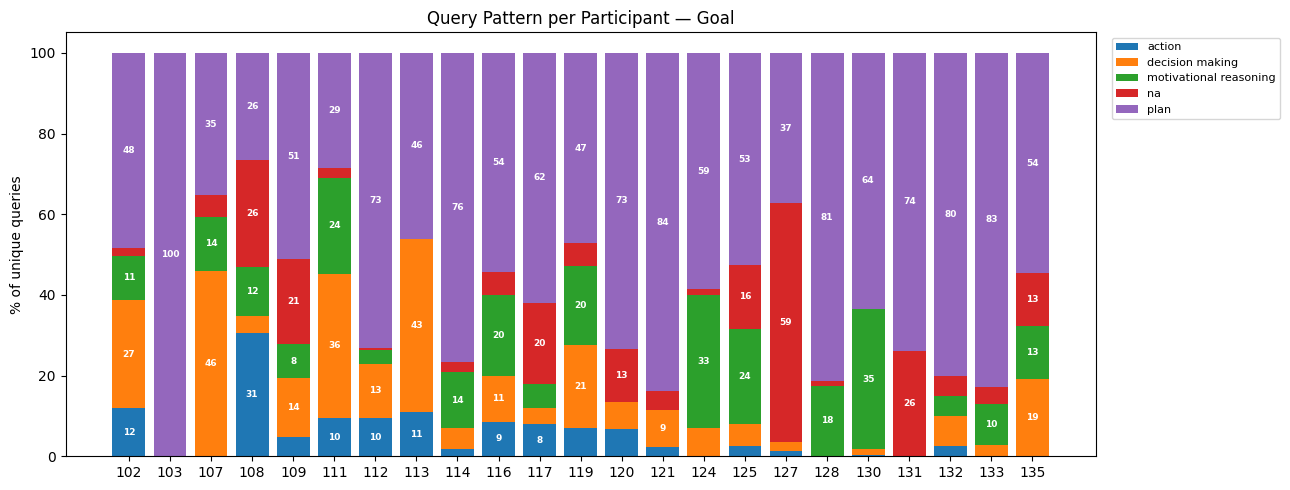

In [60]:
for name, tbl in patterns.items():
    fig, ax = plt.subplots(figsize=(13, 5))
    tbl_sorted = tbl.loc[uq.index]
    bottom = np.zeros(len(tbl_sorted))
    for i, col in enumerate(tbl_sorted.columns):
        vals  = tbl_sorted[col].values
        bars  = ax.bar(range(len(tbl_sorted)), vals, bottom=bottom,
                       label=col)
        for j, (v, b) in enumerate(zip(vals, bottom)):
            if v >= 8:
                ax.text(j, b + v / 2, f"{v:.0f}", ha="center", va="center",
                        fontsize=6.5, color="white", fontweight="bold")
        bottom += vals
    ax.set_xticks(range(len(tbl_sorted)))
    ax.set_xticklabels(tbl_sorted.index.astype(str))
    ax.set_ylabel("% of unique queries")
    ax.set_title(f"Query Pattern per Participant — {name}")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
    plt.tight_layout()